In [14]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.metrics import accuracy_score


In [2]:
df = pd.read_csv('product.csv',encoding='latin-1'  )
df.head()

,product_id,product,brand,type,length,depth,width,category,sub_category.,volume
0,P0021,"Tomato - Local, Organically Grown",Fresho,Organic Vegetables,8.0,26.0,23.0,Fruits & Vegetables,Fresh Vegetables,4784.0
1,P0028,Tomato - Green,Fresho,Marigold,3.4,11.3,12.0,Fruits & Vegetables,"Flower Bouquets, Bunches",461.0
2,P0029,"Chilli - Green, Organically Grown",Fresho,"Potato, Onion & Tomato",2.5,18.0,8.0,Fruits & Vegetables,Fresh Vegetables,360.0
3,P0030,Ginger - Organically Grown,Fresho,Organic Vegetables,9.0,9.0,37.0,Fruits & Vegetables,Herbs & Seasonings,2997.0
4,P0031,"Chilli - Green, Organically Grown",Fresho,Organic Vegetables,NaN,NaN,NaN,Fruits & Vegetables,Herbs & Seasonings,NaN


In [3]:
df.shape

(699, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   product_id     699 non-null    object 
 1   product        698 non-null    object 
 2   brand          698 non-null    object 
 3   type           699 non-null    object 
 4   length         683 non-null    float64
 5   depth          683 non-null    float64
 6   width          681 non-null    float64
 7   category       699 non-null    object 
 8   sub_category.  699 non-null    object 
 9   volume         681 non-null    float64
dtypes: float64(4), object(6)
memory usage: 54.7+ KB


In [14]:
df.drop(['volume'],axis=1,inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   product_id     699 non-null    object 
 1   product        698 non-null    object 
 2   brand          698 non-null    object 
 3   type           699 non-null    object 
 4   length         683 non-null    float64
 5   depth          683 non-null    float64
 6   width          681 non-null    float64
 7   category       699 non-null    object 
 8   sub_category.  699 non-null    object 
dtypes: float64(3), object(6)
memory usage: 49.3+ KB


In [16]:
pd.isnull(df)

,product_id,product,brand,type,length,depth,width,category,sub_category.
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...
694,False,False,False,False,False,False,False,False,False
695,False,False,False,False,False,False,False,False,False
696,False,False,False,False,False,False,False,False,False
697,False,False,False,False,False,False,False,False,False


In [17]:
pd.isnull(df).sum() 

product_id        0
product           1
brand             1
type              0
length           16
depth            16
width            18
category          0
sub_category.     0
dtype: int64

In [18]:
df.shape

(699, 9)

In [19]:
df.dropna(inplace=True)

In [20]:
df.shape

(680, 9)

In [21]:
data_test = [['2020-01-01', 100, 110, 90, 105, 1000],
             ['2020-01-02', 105, 115, 95, 110, 1200],
             ['2020-01-03', 110, 120, 100, 115, 1500]]
df_test = pd.DataFrame(data_test, columns=['date', 'open', 'high', 'low', 'close', 'volume'])
df_test

,date,open,high,low,close,volume
0,2020-01-01,100,110,90,105,1000
1,2020-01-02,105,115,95,110,1200
2,2020-01-03,110,120,100,115,1500


In [23]:
df_test.dropna(inplace=True)

In [28]:
df['width'] =df['width'].astype(int)

In [29]:
df['width'].dtype

dtype('int64')

In [30]:
df.columns

Index(['product_id', 'product', 'brand', 'type', 'length', 'depth', 'width',
       'category', 'sub_category.'],
      dtype='object')

In [31]:
df.rename(columns={'width':'Width'})

,product_id,product,brand,type,length,depth,Width,category,sub_category.
0,P0021,"Tomato - Local, Organically Grown",Fresho,Organic Vegetables,8.0,26.0,23,Fruits & Vegetables,Fresh Vegetables
1,P0028,Tomato - Green,Fresho,Marigold,3.4,11.3,12,Fruits & Vegetables,"Flower Bouquets, Bunches"
2,P0029,"Chilli - Green, Organically Grown",Fresho,"Potato, Onion & Tomato",2.5,18.0,8,Fruits & Vegetables,Fresh Vegetables
3,P0030,Ginger - Organically Grown,Fresho,Organic Vegetables,9.0,9.0,37,Fruits & Vegetables,Herbs & Seasonings
5,P0032,Ginger - Organically Grown,Fresho,Organic Vegetables,5.0,12.0,4,Fruits & Vegetables,Organic Fruits & Vegetables
...,...,...,...,...,...,...,...,...,...
694,P0605,Wafers - Aloo Chaat,Parle,Chips & Corn Snacks,0.1,14.0,9,Snacks & Branded Foods,Snacks & Namkeen
695,P0606,Milk Shake - Vanilla,Milky Mist,Chips & Corn Snacks,3.0,17.0,7,Snacks & Branded Foods,Snacks & Namkeen
696,P0613,Sandwich Biscuits Fab - Jam In Fruit Flavour,Parle,Chips & Corn Snacks,12.0,3.0,9,Snacks & Branded Foods,Snacks & Namkeen
697,P0637,7 O Click - Permasharp Stainless Blade,Gillette,Namkeen & Savoury Snacks,5.0,25.0,9,Snacks & Branded Foods,Snacks & Namkeen


In [32]:
df.describe()

,length,depth,width
count,680.000000,680.000000,680.000000
mean,7.237353,18.466176,13.283824
std,8.517753,14.275371,10.153913
min,0.000000,0.000000,0.000000
25%,3.000000,10.950000,7.000000
50%,5.000000,17.000000,10.000000
75%,8.000000,23.075000,16.000000
max,100.000000,165.000000,100.000000


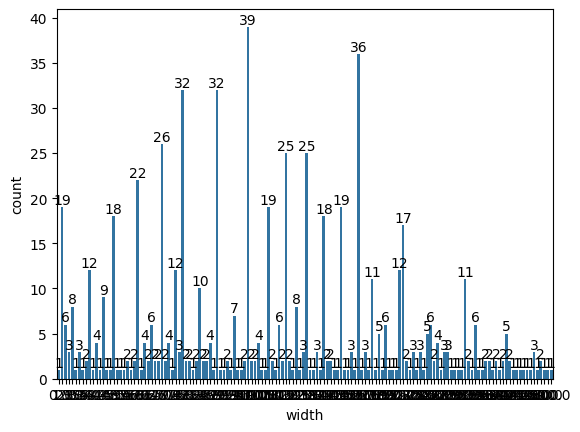

In [5]:
ax  = sns.countplot(x='width',data=df)

for p in ax.containers:
    ax.bar_label(p)

<Axes: xlabel='width', ylabel='length'>

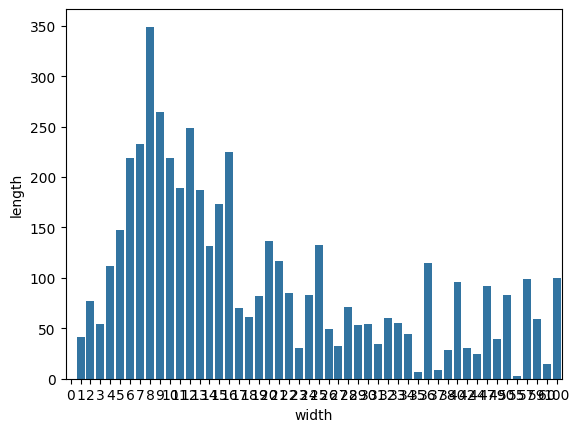

In [34]:
product_wid = df.groupby(['width'],as_index=False).sum().sort_values(by='width',ascending=False)
sns.barplot(x='width',y='length',data=product_wid)

<Axes: xlabel='product_id'>

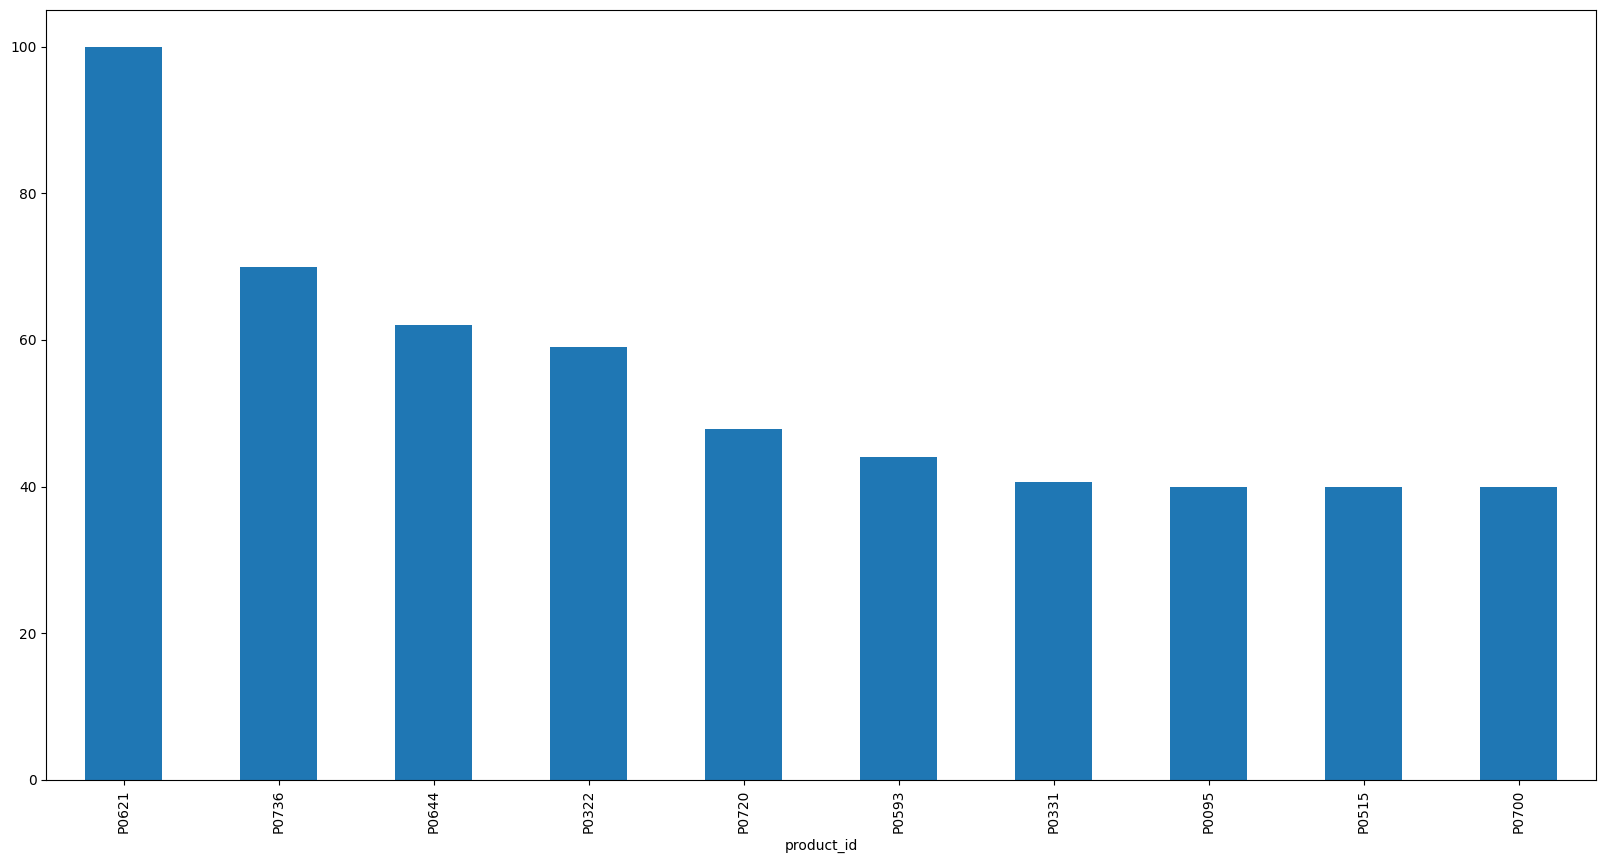

In [7]:
fig1 = plt.figure(figsize=(20,10))
df.groupby('product_id')['length'].sum().nlargest(10).sort_values(ascending=False).plot(kind='bar')

<Axes: xlabel='brand'>

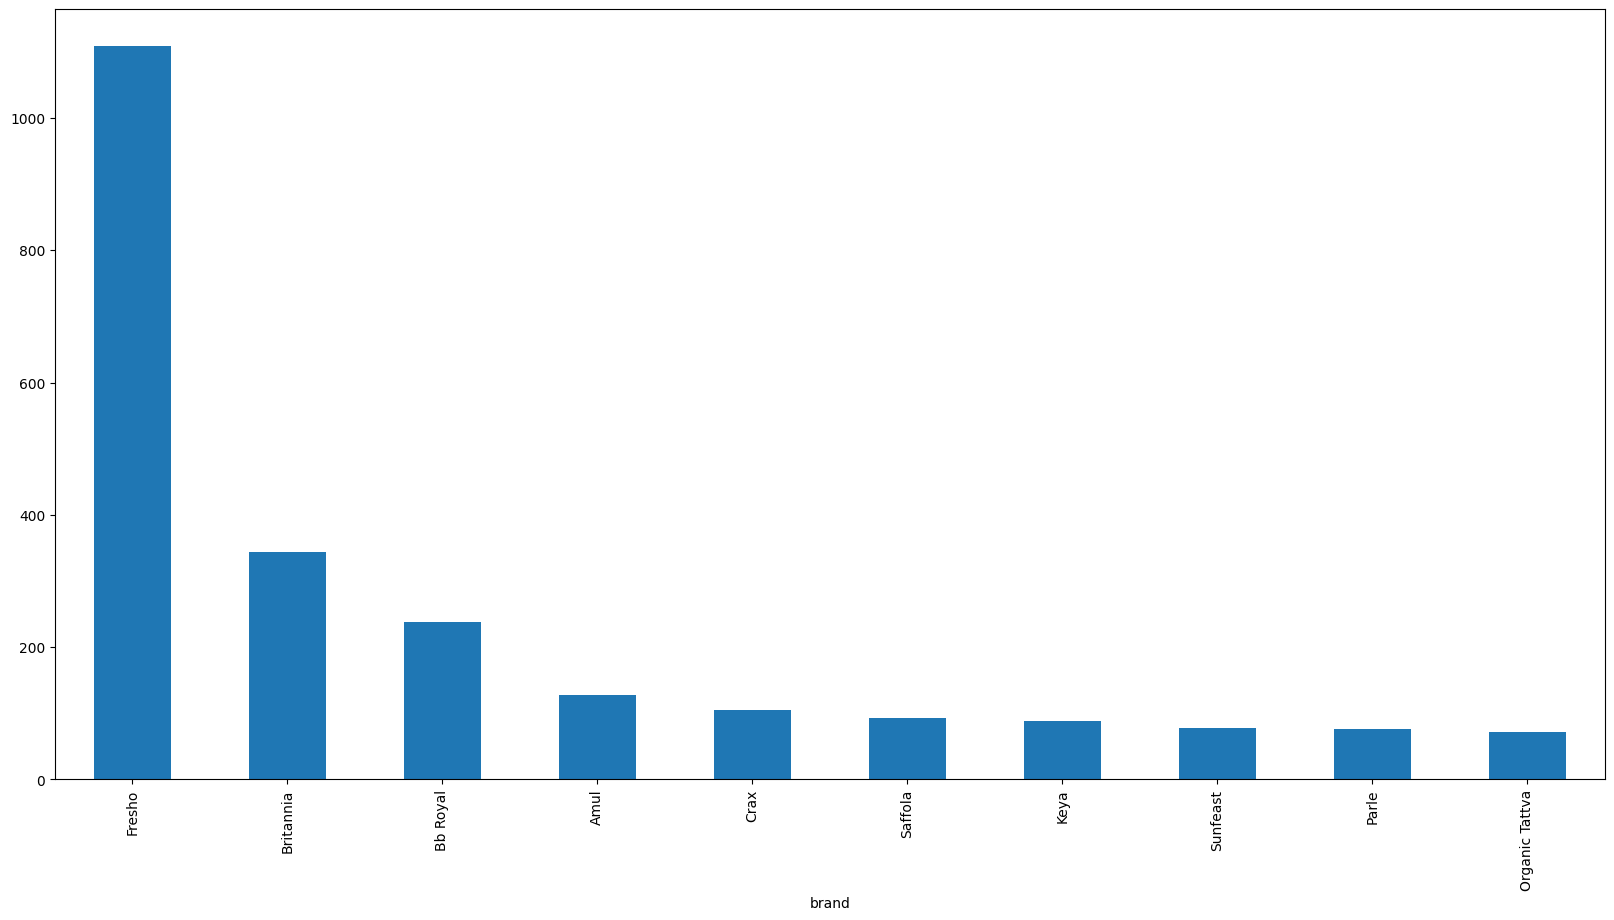

In [9]:
fig1 = plt.figure(figsize=(20,10))
df.groupby('brand')['length'].sum().nlargest(10).sort_values(ascending=False).plot(kind='bar')

<Axes: xlabel='product'>

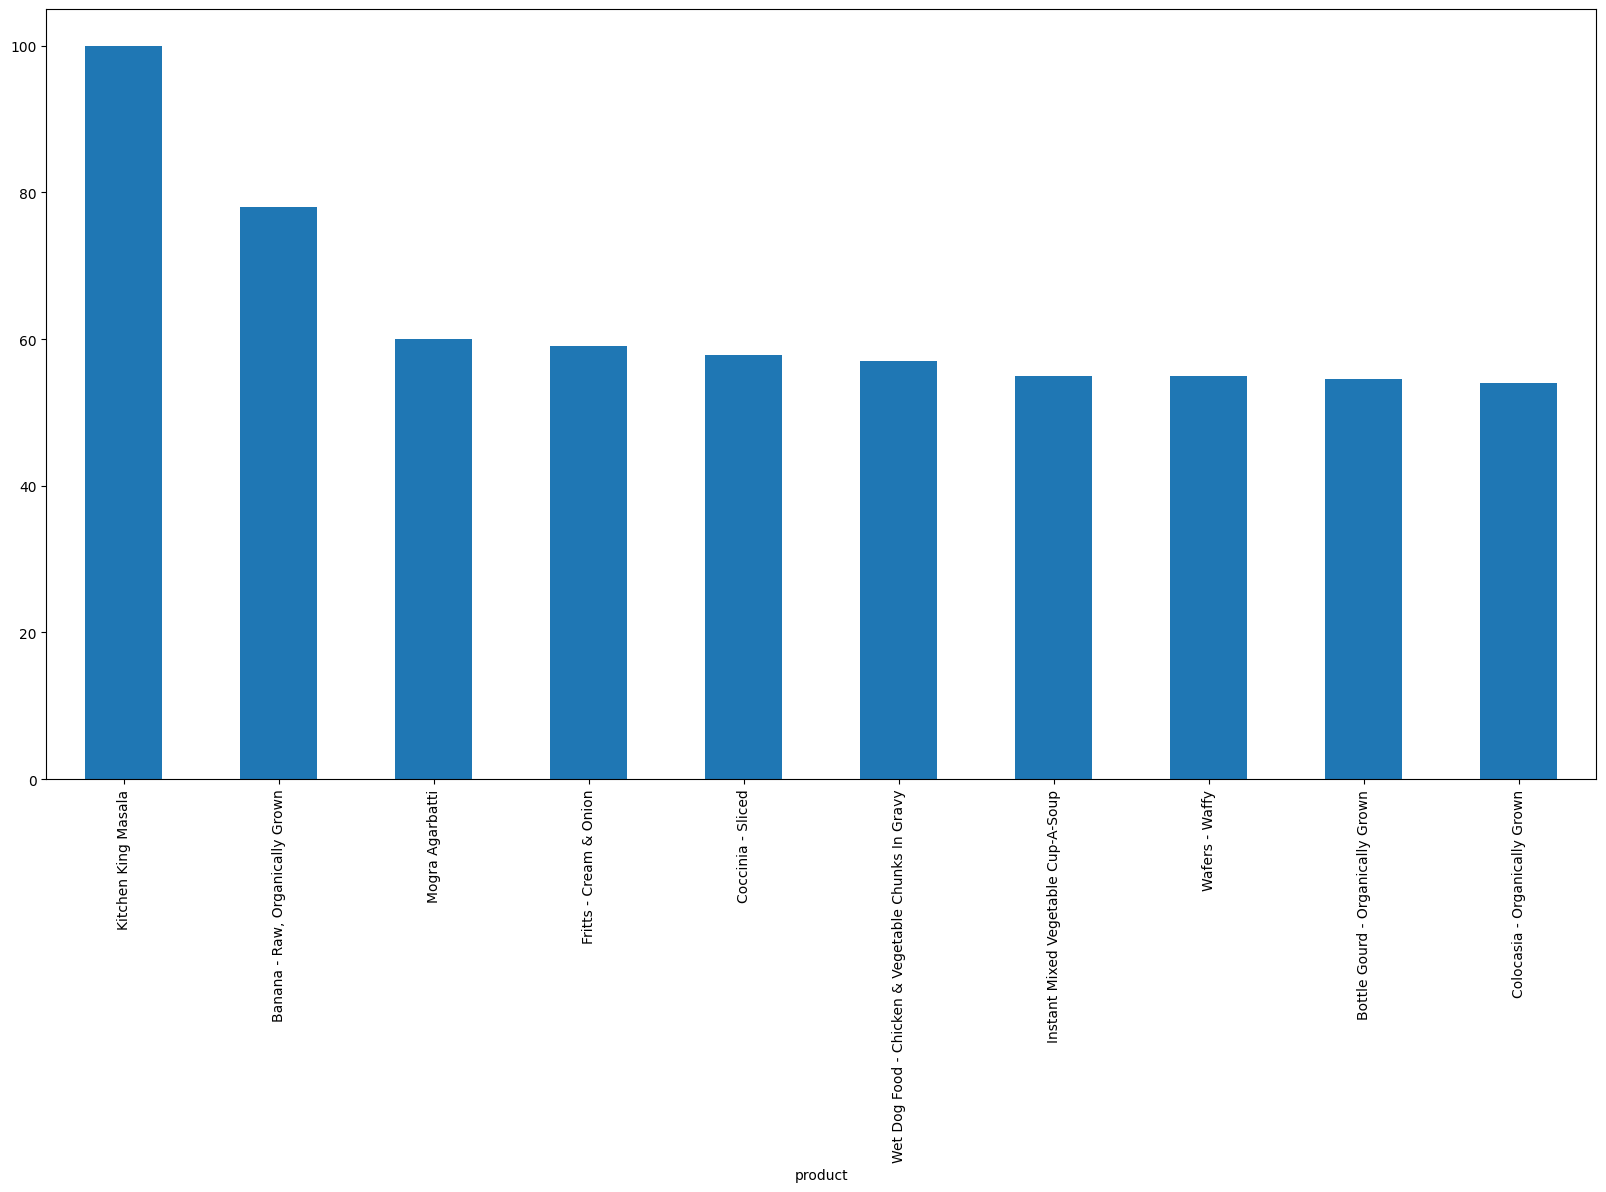

In [11]:
fig1 = plt.figure(figsize=(20,10))
df.groupby('product')['width'].sum().nlargest(10).sort_values(ascending=False).plot(kind='bar')

In [16]:
accuracy = np.mean(df['width'] == df['length'])
print("Accuracy:", accuracy)

Accuracy: 0.21316165951359084
